In [11]:
%load_ext autoreload
%autoreload 2

In [13]:
import matplotlib as mpl
# matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np
plt.style.use("default")
plt.rc("figure", figsize=[5, 5])
plt.rc("font", size=16, family="Times New Roman")
plt.rc("axes", labelsize=16, titlesize=16)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=14)
plt.rc("ytick", labelsize=14)
plt.rc("lines", linewidth=2)
mu_sb = "\u03bc"
deg_sb = "\u00b0"
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.edgecolor'] = 'inherit'
my_colors = ["#3500fc", "#830e06", "#247e0d", "#f5a721", "#7a0a7e", "#4fbdfd", "#db248e", "#ef8271", "#97cec9", "#7f7f7f", "#ff9b50"]
mpl.rcParams['axes.prop_cycle'] = cycler(color=my_colors)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["axes.formatter.use_mathtext"] = True

print("done")

done


# Electric-field validation figures



In [14]:
from ldagg.clusters import Cluster
from ldagg.constants import BOLTZMANN
from ldagg.electric import (
    ElectricFieldConfig,
    dipole_force_energy_diagnostics_on_clusters,
    dipole_forces_on_clusters,
    dipole_pair_energy,
    dipole_pair_force_on_b,
    induced_dipole,
    resolve_polarizability,
)
from ldagg.gas import Gas, particle_mass, sphere_friction
from ldagg.integrators import eb_step
FE_DENSITY = 7874.0
PRIMARY_DIAMETER = 30.0e-9
PRIMARY_RADIUS = 0.5 * PRIMARY_DIAMETER
EPS_R_AIR = 1.00058
E0 = 30.0e3 * 100.0 # kV/cm in V/m
TEMPERATURE = 300.0
GAS = Gas(temperature=TEMPERATURE)
def _draw_and_close(fig) -> None:
    fig.canvas.draw()
    plt.close(fig)
def _field_config(
    vector=(0.0, 0.0, E0),
    *,
    polarizability_model: str = "conducting_sphere",
    polarizability_si: float | None = None,
    regularization_gap: float = 0.0,
) -> ElectricFieldConfig:
    data = {
        "enabled": True,
        "vector": vector,
        "medium_relative_permittivity": EPS_R_AIR,
        "polarizability_model": polarizability_model,
        "regularization_gap": regularization_gap,
    }
    if polarizability_si is not None:
        data["polarizability_SI"] = polarizability_si
    return ElectricFieldConfig.from_mapping(data)
def _alpha_fe_conducting_sphere(diameter: float = PRIMARY_DIAMETER) -> float:
    return resolve_polarizability(_field_config(), diameter)
def _primary_dipole(vector=(0.0, 0.0, E0)) -> np.ndarray:
    return induced_dipole(_alpha_fe_conducting_sphere(), np.asarray(vector, dtype=float))
def _monomer(cluster_id: int, position) -> Cluster:
    return Cluster.monomer(
        cluster_id,
        np.asarray(position, dtype=float),
        np.zeros(3),
        PRIMARY_DIAMETER,
        density=FE_DENSITY,
        gas=GAS,
    )
def _cluster_from_relative_positions(cluster_id: int, rel_positions) -> Cluster:
    rel = np.asarray(rel_positions, dtype=float).reshape((-1, 3))
    mass = particle_mass(PRIMARY_DIAMETER, FE_DENSITY)
    friction = sphere_friction(PRIMARY_DIAMETER, GAS)
    return Cluster(
        cluster_id=cluster_id,
        rel_positions=rel,
        radii=np.full(len(rel), PRIMARY_RADIUS),
        masses=np.full(len(rel), mass),
        primary_frictions=np.full(len(rel), friction),
        position=np.zeros(3),
        velocity=np.zeros(3),
        gas=GAS,
        primary_ids=np.arange(len(rel), dtype=np.int64),
    )
def _finite_difference_force(r_vec: np.ndarray, p: np.ndarray, delta: float) -> np.ndarray:
    force = np.zeros(3)
    for axis in range(3):
        shift = np.zeros(3)
        shift[axis] = delta
        u_plus = dipole_pair_energy(r_vec + shift, p, p, eps_r=EPS_R_AIR)
        u_minus = dipole_pair_energy(r_vec - shift, p, p, eps_r=EPS_R_AIR)
        force[axis] = -(u_plus - u_minus) / (2.0 * delta)
    return force
def _two_particle_history(axis, field_vector, *, side_by_side: bool = False):
    axis = np.asarray(axis, dtype=float)
    axis /= np.linalg.norm(axis)
    separation = 2.2 * PRIMARY_DIAMETER
    clusters = [
        _monomer(0, -0.5 * separation * axis),
        _monomer(1, 0.5 * separation * axis),
    ]
    config = _field_config(vector=field_vector)
    dt = 1.0e-12 if side_by_side else 5.0e-12
    steps = 120
    rows = []
    rng = np.random.default_rng(123)
    for step in range(steps):
        disp = clusters[1].position - clusters[0].position
        distance = float(np.linalg.norm(disp))
        unit = disp / distance
        forces = dipole_forces_on_clusters(clusters, config, PRIMARY_DIAMETER)
        rel_velocity = clusters[1].velocity - clusters[0].velocity
        force_b = forces[1]
        force_b_norm = float(np.linalg.norm(force_b))
        if force_b_norm > 0.0:
            velocity_ratio = float(np.dot(clusters[1].velocity, force_b / force_b_norm))
            velocity_ratio /= force_b_norm / clusters[1].friction
        else:
            velocity_ratio = 0.0
        rows.append(
            {
                "time": step * dt,
                "gap": distance - PRIMARY_DIAMETER,
                "relative_speed": float(np.dot(rel_velocity, unit)),
                "force_axis": float(np.dot(force_b, axis)),
                "velocity_ratio": velocity_ratio,
                "drift_to_brownian": (
                    force_b_norm / clusters[1].friction * dt
                )
                / np.sqrt(6.0 * clusters[1].diffusion * dt),
            }
        )
        for cluster, force in zip(clusters, forces, strict=True):
            update = eb_step(
                cluster.position,
                cluster.velocity,
                cluster.mass,
                cluster.friction,
                force,
                dt,
                TEMPERATURE,
                rng,
                brownian=False,
            )
            cluster.position = update.position
            cluster.velocity = update.velocity
    return rows
def _force_on_probe(aggregate: Cluster, position, field_config: ElectricFieldConfig):
    probe = _monomer(999, position)
    forces, energy, *_summary = dipole_force_energy_diagnostics_on_clusters(
        [aggregate, probe],
        field_config,
        PRIMARY_DIAMETER,
    )
    return forces[1], energy


## validation 1 induced dipole and alpha scaling plots


Polarizability of Fe particle (conducting sphere model): 3.757371949620101e-34 C m^2/V


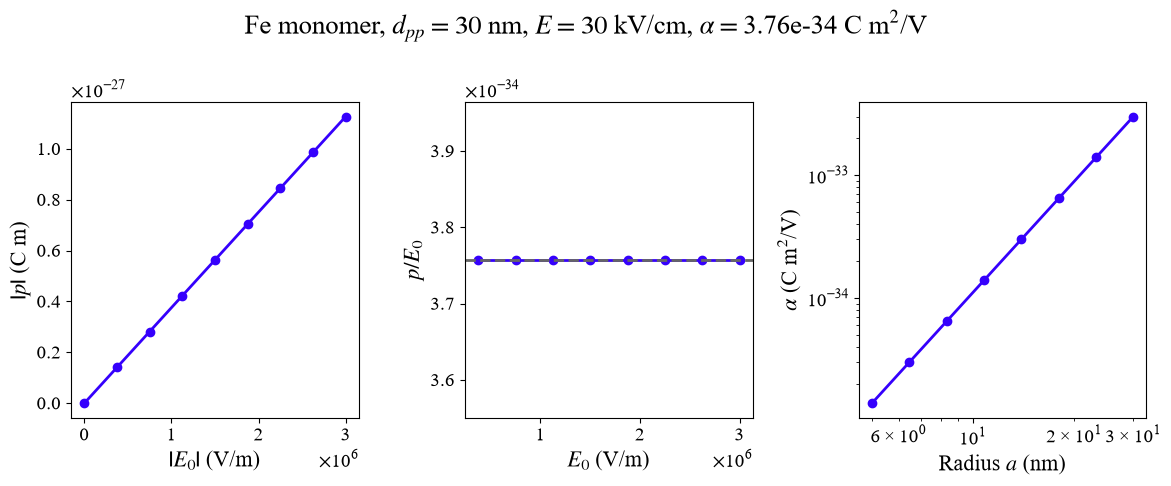

In [32]:
alpha = _alpha_fe_conducting_sphere()
print("Polarizability of Fe particle (conducting sphere model):", alpha, "C m^2/V")
fields = np.linspace(0.0, E0, 9)
p_norms = np.array([np.linalg.norm(induced_dipole(alpha, [0.0, 0.0, field])) for field in fields])
slope, intercept = np.polyfit(fields, p_norms, 1)
assert np.isclose(slope, alpha, rtol=1.0e-12)
assert abs(intercept) < 1.0e-12 * np.max(p_norms)
assert np.allclose(p_norms[1:] / fields[1:], alpha)
radii = np.geomspace(5.0e-9, 30.0e-9, 8)
alphas = np.array([resolve_polarizability(_field_config(), 2.0 * radius) for radius in radii])
log_slope, _ = np.polyfit(np.log(radii), np.log(alphas), 1)
assert np.isclose(log_slope, 3.0, atol=1.0e-12)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(fields, p_norms, "o-")
axes[0].set_xlabel("$|E_0|$ (V/m)")
axes[0].set_ylabel("$|p|$ (C m)")
axes[1].plot(fields[1:], p_norms[1:] / fields[1:], "o-")
axes[1].axhline(alpha, color="0.4", linestyle="--")
axes[1].set_xlabel("$E_0$ (V/m)")
axes[1].set_ylabel("$p / E_0$")
axes[2].loglog(radii*1e9, alphas, "o-")
axes[2].set_xlabel("Radius $a$ (nm)")
axes[2].set_ylabel("$\\alpha$ (C m$^2$/V)")
plt.suptitle("Fe monomer, $d_{pp} = 30$ nm, $E=30$ kV/cm, $\\alpha=$" + f"{alpha:.2e}" + " C m$^2$/V")
plt.tight_layout()
plt.show()


## validation 2 pair force signs plot


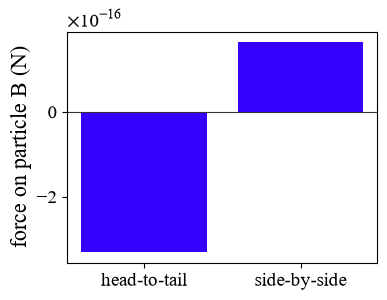

In [ ]:
# test if the force is attractive or repulsive for the two configurations: head-to-tail and side-by-side for dipoles A and B
p = _primary_dipole()
r = 4.0 * PRIMARY_DIAMETER
head = dipole_pair_force_on_b(np.array([0.0, 0.0, r]), p, p, eps_r=EPS_R_AIR)
side = dipole_pair_force_on_b(np.array([r, 0.0, 0.0]), p, p, eps_r=EPS_R_AIR)
assert abs(head[0]) < abs(head[2]) * 1.0e-14
assert head[2] < 0.0
assert side[0] > 0.0
assert abs(side[2]) < abs(side[0]) * 1.0e-14
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["head-to-tail", "side-by-side"], [head[2], side[0]])
ax.axhline(0.0, color="0.2", linewidth=0.8)
ax.set_ylabel("force on particle B (N)")
plt.show()



## validation 3 dipole energy angle magic angle plot
$U_{dd} = \frac{p^2}{4 \pi \epsilon_0 \epsilon_r r^3} (1-3 \cos ^2 \theta)$

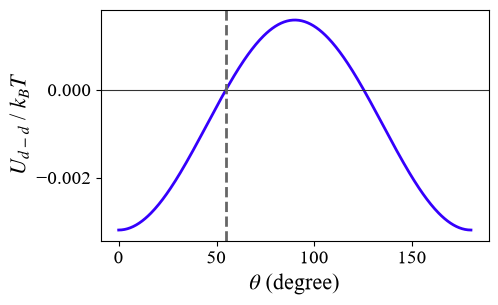

In [40]:
# compute pair energy for two equal dipoles aligned with E0 with theta the angle between the interparticle vector and E
p = _primary_dipole()
r = 4.0 * PRIMARY_DIAMETER
theta = np.linspace(0.0, np.pi, 361)
energy = np.array(
    [
        dipole_pair_energy(
            r * np.array([np.sin(value), 0.0, np.cos(value)]),
            p,
            p,
            eps_r=EPS_R_AIR,
        )
        for value in theta
    ]
)
magic = np.arccos(1.0 / np.sqrt(3.0)) # analytical zero-cross angle for energy = 0
zero_index = np.argmin(np.abs(energy[:181]))
assert energy[0] < 0.0
assert energy[180] > 0.0
assert energy[360] < 0.0
assert abs(theta[zero_index] - magic) < np.deg2rad(0.5)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.rad2deg(theta), energy / (BOLTZMANN * TEMPERATURE))
ax.axhline(0.0, color="0.2", linewidth=0.8)
ax.axvline(np.rad2deg(magic), color="0.4", linestyle="--")
ax.set_xlabel("$\\theta$ (degree)")
ax.set_ylabel("$U_{d-d}$ / $k_B T$")
plt.show()


## validation 4 force separation scaling and regularization plot


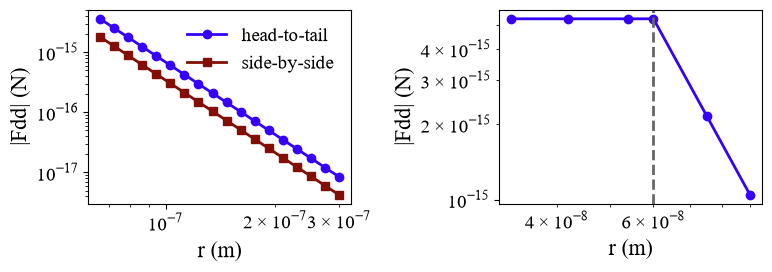

In [42]:
p = _primary_dipole()
distances = np.geomspace(2.2 * PRIMARY_DIAMETER, 10.0 * PRIMARY_DIAMETER, 18)
head = np.array(
    [
        np.linalg.norm(dipole_pair_force_on_b([0.0, 0.0, r], p, p, eps_r=EPS_R_AIR))
        for r in distances
    ]
)
side = np.array(
    [
        np.linalg.norm(dipole_pair_force_on_b([r, 0.0, 0.0], p, p, eps_r=EPS_R_AIR))
        for r in distances
    ]
)
head_slope, _ = np.polyfit(np.log(distances), np.log(head), 1)
side_slope, _ = np.polyfit(np.log(distances), np.log(side), 1)
assert np.isclose(head_slope, -4.0, atol=1.0e-12)
assert np.isclose(side_slope, -4.0, atol=1.0e-12)
assert np.allclose(head / side, 2.0)
r_reg = np.array([1.1, 1.4, 1.8, 2.0, 2.5, 3.0]) * PRIMARY_DIAMETER
min_distance = 2.0 * PRIMARY_DIAMETER
regularized = np.array(
    [
        np.linalg.norm(
            dipole_pair_force_on_b(
                [0.0, 0.0, r],
                p,
                p,
                eps_r=EPS_R_AIR,
                min_distance=min_distance,
            )
        )
        for r in r_reg
    ]
)
assert np.allclose(regularized[:4], regularized[0])
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].loglog(distances, head, "o-", label="head-to-tail")
axes[0].loglog(distances, side, "s-", label="side-by-side")
axes[0].set_xlabel("r (m)")
axes[0].set_ylabel("|Fdd| (N)")
axes[0].legend()
axes[1].loglog(r_reg, regularized, "o-", label="regularized")
axes[1].axvline(min_distance, color="0.4", linestyle="--")
axes[1].set_xlabel("r (m)")
axes[1].set_ylabel("|Fdd| (N)")
plt.tight_layout()
plt.show()


## validation 5 force matches energy gradient plot


In [ ]:
p = _primary_dipole()
r = 5.0 * PRIMARY_DIAMETER
theta = np.deg2rad(np.array([15.0, 30.0, 45.0, 70.0, 105.0, 140.0]))
errors = []
for value in theta:
    r_vec = r * np.array([np.sin(value), 0.0, np.cos(value)])
    analytic = dipole_pair_force_on_b(r_vec, p, p, eps_r=EPS_R_AIR)
    finite_difference = _finite_difference_force(r_vec, p, delta=1.0e-5 * r)
    error = np.linalg.norm(analytic - finite_difference) / (
        np.linalg.norm(finite_difference) + 1.0e-300
    )
    errors.append(error)
errors = np.asarray(errors)
assert float(np.max(errors)) < 1.0e-8
fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(np.rad2deg(theta), errors, "o-")
ax.set_xlabel("theta (degree)")
ax.set_ylabel("relative force error")
plt.show()


## validation 6 newton residual for dipole cluster forces plot


In [ ]:
rng = np.random.default_rng(8)
residuals = []
config = _field_config()
for _ in range(20):
    positions = rng.uniform(-4.0 * PRIMARY_DIAMETER, 4.0 * PRIMARY_DIAMETER, size=(5, 3))
    clusters = [_monomer(index, position) for index, position in enumerate(positions)]
    forces = dipole_forces_on_clusters(clusters, config, PRIMARY_DIAMETER)
    norms = np.linalg.norm(forces, axis=1)
    residuals.append(np.linalg.norm(np.sum(forces, axis=0)) / (np.sum(norms) + 1.0e-300))
residuals = np.asarray(residuals)
assert float(np.max(residuals)) < 1.0e-12
fig, ax = plt.subplots(figsize=(5, 3))
ax.semilogy(residuals, "o-")
ax.set_xlabel("configuration")
ax.set_ylabel("Newton residual")
plt.show()


## validation 7 field reversal and rotation invariance plot


In [ ]:
clusters_z = [
    _monomer(0, [0.0, 0.0, 0.0]),
    _monomer(1, [0.0, 0.0, 4.0 * PRIMARY_DIAMETER]),
]
forces_plus = dipole_forces_on_clusters(clusters_z, _field_config([0.0, 0.0, E0]), PRIMARY_DIAMETER)
forces_minus = dipole_forces_on_clusters(clusters_z, _field_config([0.0, 0.0, -E0]), PRIMARY_DIAMETER)
assert np.allclose(forces_plus, forces_minus)
clusters_x = [
    _monomer(0, [0.0, 0.0, 0.0]),
    _monomer(1, [4.0 * PRIMARY_DIAMETER, 0.0, 0.0]),
]
forces_x = dipole_forces_on_clusters(clusters_x, _field_config([E0, 0.0, 0.0]), PRIMARY_DIAMETER)
assert np.isclose(forces_x[1, 0], forces_plus[1, 2])
assert np.isclose(forces_x[1, 1], forces_plus[1, 0])
assert np.isclose(forces_x[1, 2], forces_plus[1, 1])
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(forces_plus[1], "o-", label="+E z")
ax.plot(forces_minus[1], "s--", label="-E z")
ax.plot(forces_x[1], "^-", label="rotated x")
ax.set_ylabel("force on B (N)")
ax.legend()
plt.show()


## validation 9 deterministic trajectory signs and velocity response plot


In [ ]:
head = _two_particle_history([0.0, 0.0, 1.0], [0.0, 0.0, E0])
side = _two_particle_history([1.0, 0.0, 0.0], [0.0, 0.0, E0], side_by_side=True)
head_gap = np.array([row["gap"] for row in head])
side_gap = np.array([row["gap"] for row in side])
head_force = np.array([row["force_axis"] for row in head])
side_force = np.array([row["force_axis"] for row in side])
velocity_ratio = np.array([row["velocity_ratio"] for row in head])
assert head_gap[-1] < head_gap[0]
assert np.all(head_force < 0.0)
assert side_gap[-1] > side_gap[0]
assert np.all(side_force > 0.0)
assert velocity_ratio[-1] > velocity_ratio[1]
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].plot([row["time"] for row in head], head_gap, label="head")
axes[0].plot([row["time"] for row in side], side_gap, label="side")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("surface gap (m)")
axes[0].legend()
axes[1].plot([row["time"] for row in head], head_force, label="head force")
axes[1].plot([row["time"] for row in side], side_force, label="side force")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("axis force on B (N)")
axes[1].legend()
axes[2].plot([row["time"] for row in head], velocity_ratio)
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("v_parallel / (F/f)")
plt.show()


## validation 10 force vector maps around dimer and trimer plot


In [ ]:
config = _field_config([0.0, 0.0, E0])
z_dimer = _cluster_from_relative_positions(
    0,
    [[0.0, 0.0, -0.5 * PRIMARY_DIAMETER], [0.0, 0.0, 0.5 * PRIMARY_DIAMETER]],
)
x_dimer = _cluster_from_relative_positions(
    0,
    [[-0.5 * PRIMARY_DIAMETER, 0.0, 0.0], [0.5 * PRIMARY_DIAMETER, 0.0, 0.0]],
)
z_trimer = _cluster_from_relative_positions(
    0,
    [[0.0, 0.0, -PRIMARY_DIAMETER], [0.0, 0.0, 0.0], [0.0, 0.0, PRIMARY_DIAMETER]],
)
top_force, _ = _force_on_probe(z_dimer, [0.0, 0.0, 2.5 * PRIMARY_DIAMETER], config)
bottom_force, _ = _force_on_probe(z_dimer, [0.0, 0.0, -2.5 * PRIMARY_DIAMETER], config)
side_force, _ = _force_on_probe(z_dimer, [2.5 * PRIMARY_DIAMETER, 0.0, 0.0], config)
trimer_top_force, _ = _force_on_probe(z_trimer, [0.0, 0.0, 3.5 * PRIMARY_DIAMETER], config)
assert top_force[2] < 0.0
assert bottom_force[2] > 0.0
assert side_force[0] > 0.0
assert trimer_top_force[2] < 0.0
aggregates = [z_dimer, x_dimer, z_trimer]
titles = ["z dimer, E z", "x dimer, E z", "z trimer, E z"]
grid = np.linspace(-4.0 * PRIMARY_DIAMETER, 4.0 * PRIMARY_DIAMETER, 15)
x_grid, z_grid = np.meshgrid(grid, grid)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
for ax, aggregate, title in zip(axes, aggregates, titles, strict=True):
    fx = np.full_like(x_grid, np.nan, dtype=float)
    fz = np.full_like(z_grid, np.nan, dtype=float)
    energy = np.full_like(z_grid, np.nan, dtype=float)
    centers = aggregate.absolute_centers
    for index in np.ndindex(x_grid.shape):
        position = np.array([x_grid[index], 0.0, z_grid[index]])
        if np.min(np.linalg.norm(centers - position[None, :], axis=1)) <= 1.1 * PRIMARY_DIAMETER:
            continue
        force, pair_energy = _force_on_probe(aggregate, position, config)
        fx[index] = force[0]
        fz[index] = force[2]
        energy[index] = pair_energy / (BOLTZMANN * TEMPERATURE)
    ax.contourf(x_grid / PRIMARY_DIAMETER, z_grid / PRIMARY_DIAMETER, energy, levels=12)
    ax.quiver(x_grid / PRIMARY_DIAMETER, z_grid / PRIMARY_DIAMETER, fx, fz)
    ax.scatter(centers[:, 0] / PRIMARY_DIAMETER, centers[:, 2] / PRIMARY_DIAMETER, s=60, c="white")
    ax.set_title(title)
    ax.set_xlabel("x / d")
    ax.set_ylabel("z / d")
plt.show()


## validation 11 drift to brownian ratio plot


In [ ]:
head = _two_particle_history([0.0, 0.0, 1.0], [0.0, 0.0, E0])
time = np.array([row["time"] for row in head])
ratio = np.array([row["drift_to_brownian"] for row in head])
assert np.all(np.isfinite(ratio))
assert np.all(ratio > 0.0)
assert ratio[-1] > ratio[0]
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(time, ratio)
ax.axhline(1.0, color="0.4", linestyle="--")
ax.set_xlabel("time (s)")
ax.set_ylabel("drift/Brownian RMS step")
plt.show()
